# 8.0 - Knowledge Distillation (three methods compared)

The SIZE axis, done as a proper method comparison. A MobileNetV3-Small + LSTM student is
trained to imitate the ResNet50 teacher, following the three approaches from the PyTorch
knowledge-distillation tutorial:

- **CE + KD**       : soft targets, KL on temperature-softened logits (T=2), 0.75 CE + 0.25 KD
- **CE + Cosine**   : CosineEmbeddingLoss between the student projection and the teacher embedding
- **CE + RegressorMSE** : MSE between them; the student's projector (128 -> 256) is the regressor

Two baselines frame them: the teacher itself, and the student trained with no teacher at
all. Every student starts from the same seed and trains with the same schedule; only the
loss changes, so the ranking is attributable to the method. The tutorial's own CIFAR-10
run found RegressorMSE best (71.37%) - we check what wins here.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "embeddings"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "PASTE_YOUR_KAGGLE_KEY"

## **Download DATASET**

MobileNet features are new, so the clips are rebuilt from video here.

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
GPU       : Tesla T4 (15.6 GB)
Classes   : base=10 t1=10 t2=10 t3=10 t4=10


42

## **Load Cache and Teacher Head**

The teacher is the winning CL head from notebook 4. Its logits are the soft targets for
KD; its 256-d embedding is the target for the Cosine and MSE methods.

In [5]:
CACHE, LSTM_STATE, META = load_feature_cache(cfg.FEAT_CACHE)

ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
check_cache_labels(META, ALL_CLASSES_LIST)
class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

Loaded 9 tensors, 526 MB in RAM
  per clip: (16, 2048)


In [6]:
TEACHER_ARM = "replay_lwf"
teacher_head_path = f"{cfg.CKPT_DIR}/head_{TEACHER_ARM}.pt"
if not os.path.exists(teacher_head_path):
    raise FileNotFoundError(f"No teacher head at {teacher_head_path}. Run notebook 4.6 first, or set TEACHER_ARM.")

teacher_head = make_temporal_head(len(ALL_CLASSES_LIST), lstm_state=LSTM_STATE, device=device)
teacher_head.load_state_dict(torch.load(teacher_head_path, map_location=device))
teacher_head.eval()
print(f"teacher head: {teacher_head_path}")

teacher head: /content/drive/MyDrive/apai/checkpoints/head_replay_lwf.pt


## **Teacher Targets**

The teacher's logits and embeddings for every cached training clip, and its own test
accuracy for the comparison row.

In [7]:
teacher_logits_train, ty1 = head_logits(teacher_head, CACHE, [0, 1, 2], device, "train")
teacher_emb_train,    ty2 = head_embeddings(teacher_head, CACHE, [0, 1, 2], device, "train")

te_s = torch.cat([CACHE[f"t{t}_test"][0] for t in [0, 1, 2]])
te_y = torch.cat([CACHE[f"t{t}_test"][1] for t in [0, 1, 2]])
teacher_acc = eval_head(teacher_head, te_s, te_y, device)
print(f"teacher test accuracy: {teacher_acc:.2%}")

teacher test accuracy: 77.40%


## **Rebuild Clips and Extract MobileNet Features**

The clips are regenerated with the same group-disjoint split (preprocessing skips existing
files), then a MobileNetV3-Small backbone turns them into (16, 576) features. Loaders are
shuffle-free, so their order matches the cache the teacher targets came from.

In [8]:
student = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST), hidden_size=cfg.STUDENT_HIDDEN).to(device)
mobile_backbone = nn.Sequential(student.backbone, student.pool).to(device).eval()

ROOTS = [cfg.BASE_ROOT, cfg.TASK1_ROOT, cfg.TASK2_ROOT]
CLS   = [cfg.SELECTED_CLASSES, cfg.TASK_1, cfg.TASK_2]
print(f"student backbone dim: {student.BACKBONE_DIM}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 187MB/s]

student backbone dim: 576


In [9]:
for classes, root in zip(CLS, ROOTS):
    split_map = build_group_split(classes, train_groups=18, val_groups=3)
    preprocess_group_split(split_map, classes, output_root=root)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_base

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_task1

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_task2


In [10]:
PIN = device.type == "cuda"
feats = {"train": [], "val": [], "test": []}
labs  = {"train": [], "val": [], "test": []}

for root, classes in zip(ROOTS, CLS):
    for split in ["train", "val", "test"]:
        ds, ld = build_clip_loader(root, classes, class_to_idx, split, cfg.BATCH_SIZE, cfg.NUM_WORKERS, PIN)
        f, y = extract_frame_features(mobile_backbone, ld, device, student.BACKBONE_DIM, torch.float32)
        feats[split].append(f)
        labs[split].append(y)

student_train_s = torch.cat(feats["train"]); student_train_y = torch.cat(labs["train"])
student_val_s   = torch.cat(feats["val"]);   student_val_y   = torch.cat(labs["val"])
student_test_s  = torch.cat(feats["test"]);  student_test_y  = torch.cat(labs["test"])

print(f"student train {tuple(student_train_s.shape)}  val {tuple(student_val_s.shape)}  test {tuple(student_test_s.shape)}")

  Frame features: 100%|██████████| 29/29 [00:09<00:00,  3.03it/s]


student train (2880, 16, 576)  val (476, 16, 576)  test (655, 16, 576)


The alignment check. If it fails the teacher targets and student features are in different orders.

In [11]:
assert torch.equal(student_train_y, ty1) and torch.equal(ty1, ty2), "train features and teacher targets misaligned"
assert torch.equal(student_test_y, te_y), "test features and teacher labels misaligned"
print("alignment OK")

alignment OK


## **Train the Students**

Same seed, same schedule for all four; only the distillation objective differs. Weights
follow the tutorial: 0.75 CE + 0.25 distillation, T=2, Adam.

In [12]:
KD_EPOCHS, KD_LR, KD_BATCH, KD_T = 10, 1e-3, 64, 2.0
results = {}

In [13]:
set_seed(cfg.SEED)
head_none = make_temporal_head(len(ALL_CLASSES_LIST), lstm_state=None, device=device,
                               backbone_dim=student.BACKBONE_DIM, hidden_size=cfg.STUDENT_HIDDEN,
                               teacher_hidden=cfg.TEACHER_HIDDEN, dropout_p=cfg.STUDENT_DROPOUT)
head_none = train_student(head_none, student_train_s, student_train_y, student_val_s, student_val_y,
                          device, mode="none", epochs=KD_EPOCHS, lr=KD_LR, batch_size=KD_BATCH)
results["none"] = eval_head(head_none, student_test_s, student_test_y, device)

[  none] epoch 01/10 | val 62.82%
[  none] epoch 02/10 | val 69.96%
[  none] epoch 03/10 | val 72.48%
[  none] epoch 04/10 | val 76.47%
[  none] epoch 05/10 | val 76.68%
[  none] epoch 06/10 | val 74.16%
[  none] epoch 07/10 | val 76.68%
[  none] epoch 08/10 | val 75.00%
[  none] epoch 09/10 | val 72.48%
[  none] epoch 10/10 | val 76.05%
  -> [none] best val 76.68%


In [14]:
set_seed(cfg.SEED)
head_kd = make_temporal_head(len(ALL_CLASSES_LIST), lstm_state=None, device=device,
                             backbone_dim=student.BACKBONE_DIM, hidden_size=cfg.STUDENT_HIDDEN,
                             teacher_hidden=cfg.TEACHER_HIDDEN, dropout_p=cfg.STUDENT_DROPOUT)
head_kd = train_student(head_kd, student_train_s, student_train_y, student_val_s, student_val_y,
                        device, mode="kd", teacher_logits=teacher_logits_train,
                        epochs=KD_EPOCHS, lr=KD_LR, batch_size=KD_BATCH, T=KD_T)
results["kd"] = eval_head(head_kd, student_test_s, student_test_y, device)

[    kd] epoch 01/10 | val 63.45%
[    kd] epoch 02/10 | val 69.96%
[    kd] epoch 03/10 | val 73.74%
[    kd] epoch 04/10 | val 74.58%
[    kd] epoch 05/10 | val 74.79%
[    kd] epoch 06/10 | val 75.21%
[    kd] epoch 07/10 | val 77.94%
[    kd] epoch 08/10 | val 78.78%
[    kd] epoch 09/10 | val 77.10%
[    kd] epoch 10/10 | val 78.78%
  -> [kd] best val 78.78%


In [15]:
set_seed(cfg.SEED)
head_cos = make_temporal_head(len(ALL_CLASSES_LIST), lstm_state=None, device=device,
                              backbone_dim=student.BACKBONE_DIM, hidden_size=cfg.STUDENT_HIDDEN,
                              teacher_hidden=cfg.TEACHER_HIDDEN, dropout_p=cfg.STUDENT_DROPOUT)
head_cos = train_student(head_cos, student_train_s, student_train_y, student_val_s, student_val_y,
                         device, mode="cosine", teacher_emb=teacher_emb_train,
                         epochs=KD_EPOCHS, lr=KD_LR, batch_size=KD_BATCH)
results["cosine"] = eval_head(head_cos, student_test_s, student_test_y, device)

[cosine] epoch 01/10 | val 60.92%
[cosine] epoch 02/10 | val 69.96%
[cosine] epoch 03/10 | val 72.69%
[cosine] epoch 04/10 | val 76.47%
[cosine] epoch 05/10 | val 73.95%
[cosine] epoch 06/10 | val 76.47%
[cosine] epoch 07/10 | val 75.63%
[cosine] epoch 08/10 | val 77.31%
[cosine] epoch 09/10 | val 76.68%
[cosine] epoch 10/10 | val 76.68%
  -> [cosine] best val 77.31%


In [16]:
set_seed(cfg.SEED)
head_mse = make_temporal_head(len(ALL_CLASSES_LIST), lstm_state=None, device=device,
                              backbone_dim=student.BACKBONE_DIM, hidden_size=cfg.STUDENT_HIDDEN,
                              teacher_hidden=cfg.TEACHER_HIDDEN, dropout_p=cfg.STUDENT_DROPOUT)
head_mse = train_student(head_mse, student_train_s, student_train_y, student_val_s, student_val_y,
                         device, mode="mse", teacher_emb=teacher_emb_train,
                         epochs=KD_EPOCHS, lr=KD_LR, batch_size=KD_BATCH)
results["mse"] = eval_head(head_mse, student_test_s, student_test_y, device)

[   mse] epoch 01/10 | val 61.76%
[   mse] epoch 02/10 | val 70.17%
[   mse] epoch 03/10 | val 73.53%
[   mse] epoch 04/10 | val 76.68%
[   mse] epoch 05/10 | val 73.53%
[   mse] epoch 06/10 | val 75.84%
[   mse] epoch 07/10 | val 73.74%
[   mse] epoch 08/10 | val 76.89%
[   mse] epoch 09/10 | val 77.73%
[   mse] epoch 10/10 | val 77.31%
  -> [mse] best val 77.73%


## **Comparison**

The five numbers, in the tutorial's format.

In [17]:
print(f"Teacher accuracy: {teacher_acc*100:.2f}%")
print(f"Student accuracy without teacher: {results['none']*100:.2f}%")
print(f"Student accuracy with CE + KD: {results['kd']*100:.2f}%")
print(f"Student accuracy with CE + CosineLoss: {results['cosine']*100:.2f}%")
print(f"Student accuracy with CE + RegressorMSE: {results['mse']*100:.2f}%")

best = max(results, key=results.get)
print(f"\nbest student method: {best}  ({results[best]*100:.2f}%)")

Teacher accuracy: 77.40%
Student accuracy without teacher: 70.53%
Student accuracy with CE + KD: 73.28%
Student accuracy with CE + CosineLoss: 72.52%
Student accuracy with CE + RegressorMSE: 72.06%

best student method: kd  (73.28%)


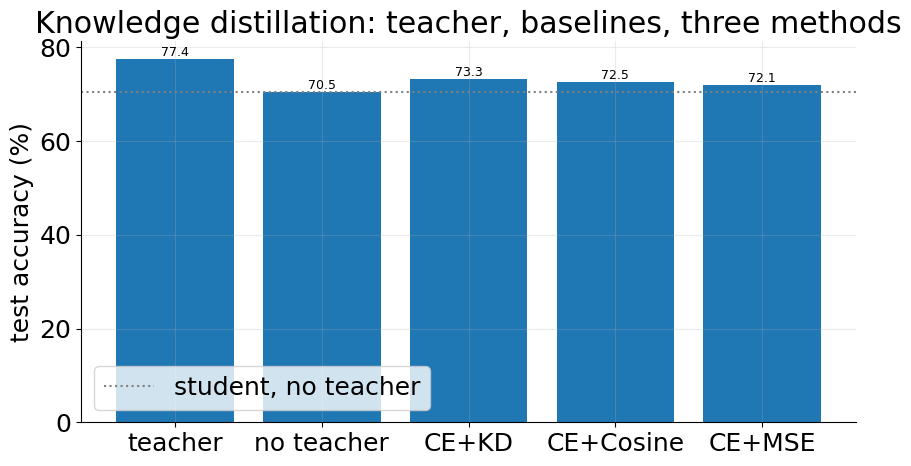

In [18]:
names  = ["teacher", "no teacher", "CE+KD", "CE+Cosine", "CE+MSE"]
scores = [teacher_acc, results["none"], results["kd"], results["cosine"], results["mse"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(names, [s * 100 for s in scores])
ax.axhline(results["none"] * 100, ls=":", color="gray", label="student, no teacher")
ax.set_ylabel("test accuracy (%)")
ax.set_title("Knowledge distillation: teacher, baselines, three methods")
ax.legend()
for b, s in zip(bars, scores):
    ax.annotate(f"{s*100:.1f}", (b.get_x() + b.get_width() / 2, s * 100),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/stage8_kd_methods.png", dpi=150, bbox_inches="tight")
plt.show()

Confusion matrix for the winning student, on the real test features.

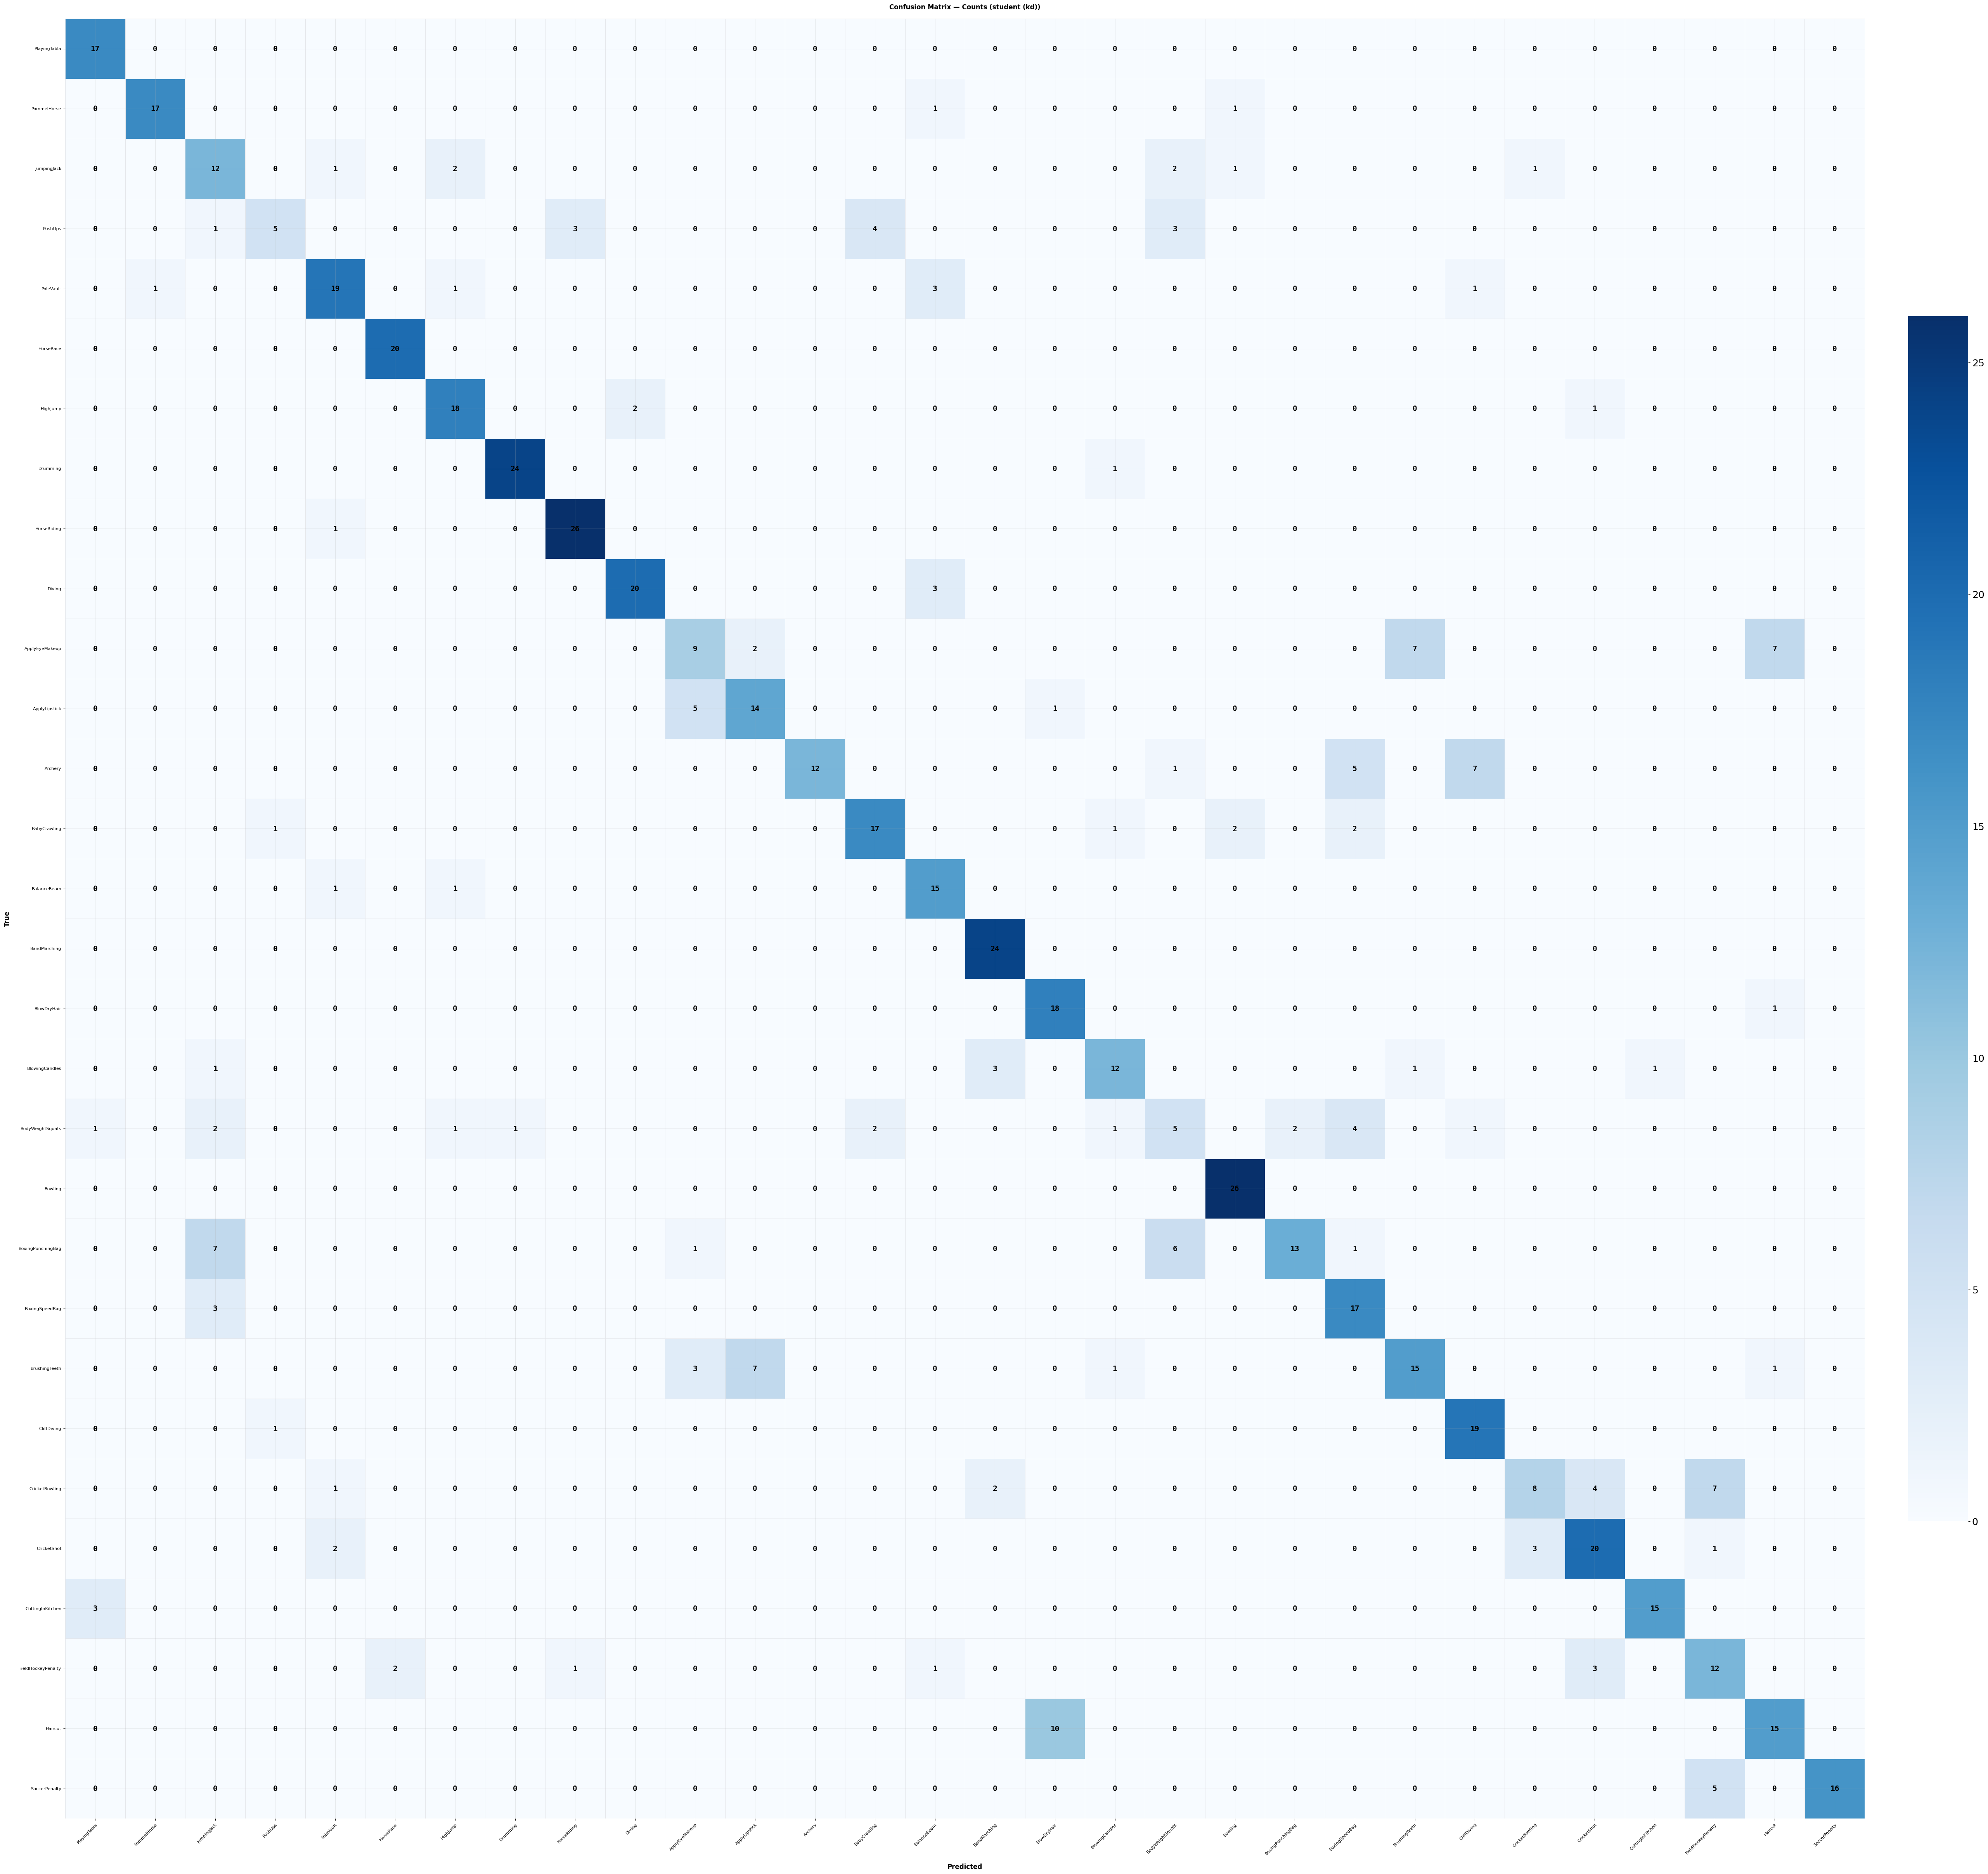

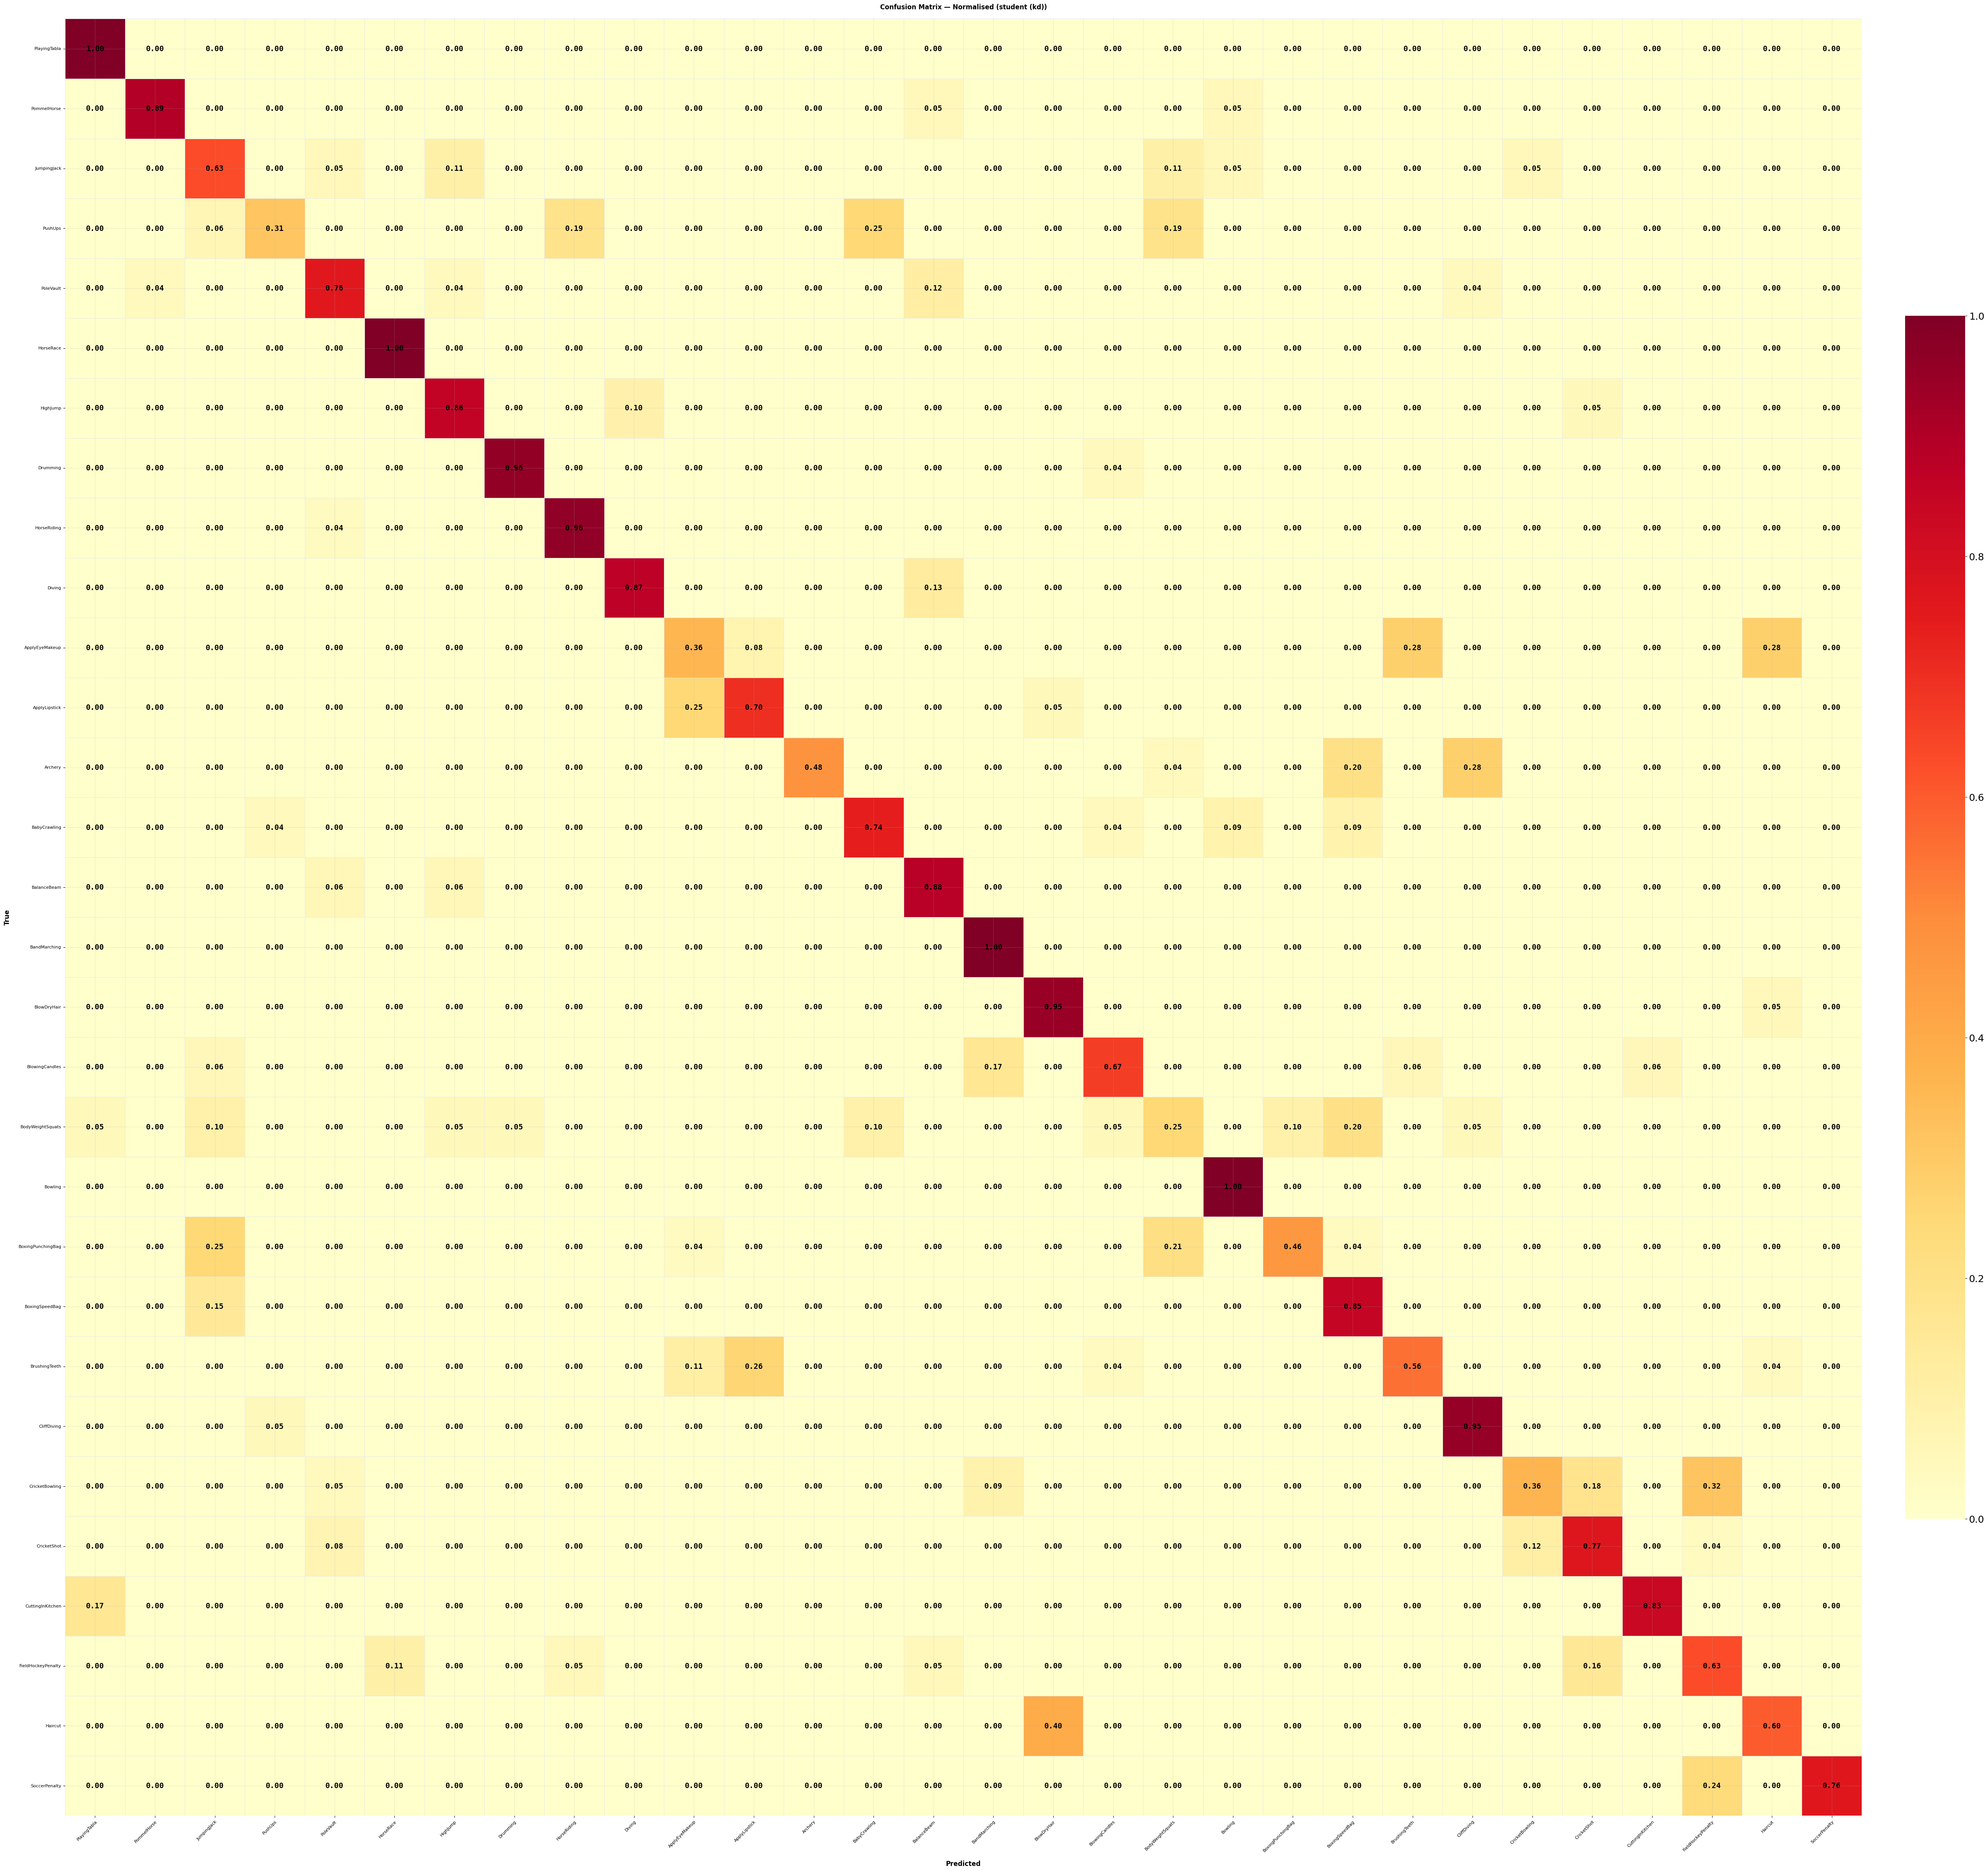

In [19]:
best_head = {"none": head_none, "kd": head_kd, "cosine": head_cos, "mse": head_mse}[best]
with torch.no_grad():
    logits, _ = best_head(student_test_s.to(device), training=False)
    best_preds = logits.argmax(1).cpu().numpy()

plot_confusion_matrix(
    student_test_y.numpy(), best_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = f"student ({best})",
    save_path    = f"{cfg.RESULTS_DIR}/stage8_cm_student",
)

## **Save**

Every number, the winning student head, and the assembled full student model.

In [20]:
student_params = sum(p.numel() for p in student.parameters())
TEACHER_PARAMS = 25_871_946   # ResNet50 + LSTM, from notebook 1.0

payload = {
    "stage":          "8_distillation",
    "teacher_arm":    TEACHER_ARM,
    "teacher_acc":    float(teacher_acc),
    "student_none":   float(results["none"]),
    "student_kd":     float(results["kd"]),
    "student_cosine": float(results["cosine"]),
    "student_mse":    float(results["mse"]),
    "best_method":    best,
    "student_acc":    float(results[best]),
    "student_params": int(student_params),
    "teacher_params": int(TEACHER_PARAMS),
}

os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
with open(f"{cfg.RESULTS_DIR}/stage8_kd.json", "w") as f:
    json.dump(payload, f, indent=2, default=float)

restore_head_to_student(student, best_head)
torch.save(best_head.state_dict(), f"{cfg.CKPT_DIR}/student_head.pt")
torch.save(student.state_dict(),   f"{cfg.CKPT_DIR}/student_ucf101.pt")

print(f"teacher {TEACHER_PARAMS:,} params -> student {student_params:,} ({TEACHER_PARAMS/student_params:.1f}x smaller)")
print(f"Saved -> {cfg.RESULTS_DIR}/stage8_kd.json")

  Restored: head.norm + head.classifier -> student.norm + student.fc
teacher 25,871,946 params -> student 1,292,606 (20.0x smaller)
Saved -> /content/drive/MyDrive/apai/results/stage8_kd.json
